Description...

In [2]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Run Configuration

In [3]:
RUNS_INFO =  {  'Ar': [ # July 2026
                        # {'run_number': 16047, 'extra': ''    },
                        # {'run_number': 16057, 'extra': ''    },
                        {'run_number': 16047, 'extra': '20260727'},  # Changes in Irene by Gonzalo
                        {'run_number': 16057, 'extra': '20260727'}
                      ],

                'Xe': [

                      ]
             }

In [4]:
SELECTION_CRITERIA = {  'Ar': [ ("Multiplicities", lambda x: (x['nS1'].sum() == 1) & (x['nS2'].sum() == 1))
                              , ("S1 Width"      , lambda x: (0      <= x['S1w'].sum() <= 2.5e3 ))    # In [ns]
                              , ("S1 Time"       , lambda x: (1000e3 <= x['S1t'].sum()          ))    # In [ns]
                              , ("S2 Width"      , lambda x: (0      <= x['S2w'].sum() <= 100   ))    # In [μs]
                              , ("S2 Time"       , lambda x: (          x['S2t'].sum() <= 1650e3))    # In [ns]
                              ],  
                             
                        'Xe': [

                              ]
                      }

## Reconstructed Data

In [5]:
DORO_DICT = {}

for run in RUNS_INFO['Ar']:
    run_id = run['run_number']
    extra  = run['extra']
    
    # Construct a clean, descriptive dictionary key
    key = f"{run_id}_v{extra}" if extra else f"{run_id}"
    # Load and assign the data
    DORO_DICT[key] = crudo.dm.load_run_data(run_id, trigger2=False, extra=extra)

SEL_DICT = {key : pd.DataFrame() for key in DORO_DICT.keys()}

/DST/Events: Run 16047 successfully loaded with data shape: (84702, 26)
/DST/Events: Run 16057 successfully loaded with data shape: (130400, 26)


In [6]:
DORO_DICT

{'16047_v20260727':        event          time  s1_peak  s2_peak  nS1  nS2     S1w        S1h  \
 0          1  1.784798e+09        0        0    1    1   375.0   9.748066   
 1          8  1.784798e+09        0        0    1    1  1075.0  18.987965   
 2         15  1.784798e+09        0        0    1    1   300.0  13.149719   
 3         22  1.784798e+09    65535        0    0    1     NaN        NaN   
 4         29  1.784798e+09        0        0    1    1  1150.0  19.960472   
 ...      ...           ...      ...      ...  ...  ...     ...        ...   
 84697  73150  1.784884e+09    65535        0    0    1     NaN        NaN   
 84698  73157  1.784884e+09        0        0    1    1   550.0  15.086307   
 84699  73164  1.784884e+09        0        0    1    1   300.0  11.127295   
 84700  73171  1.784884e+09        0        0    1    1  1300.0  14.107035   
 84701  73178  1.784884e+09        0        0    1    1   375.0  12.299737   
 
               S1e        S1t  ...  Nsipm  

# Base Distributions (NO CUTS!)

## Radial

Run 16047_v20260727:
  - R² = [1.43, 1999996000002.00] mm²


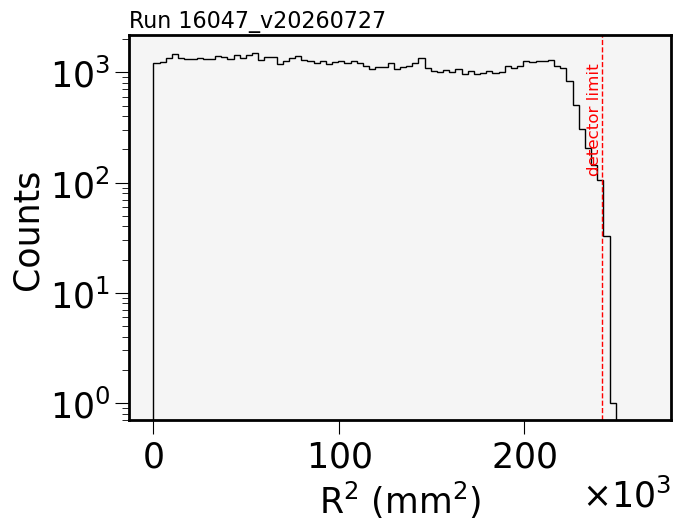

Run 16057_v20260727:
  - R² = [13.99, 1999996000002.00] mm²


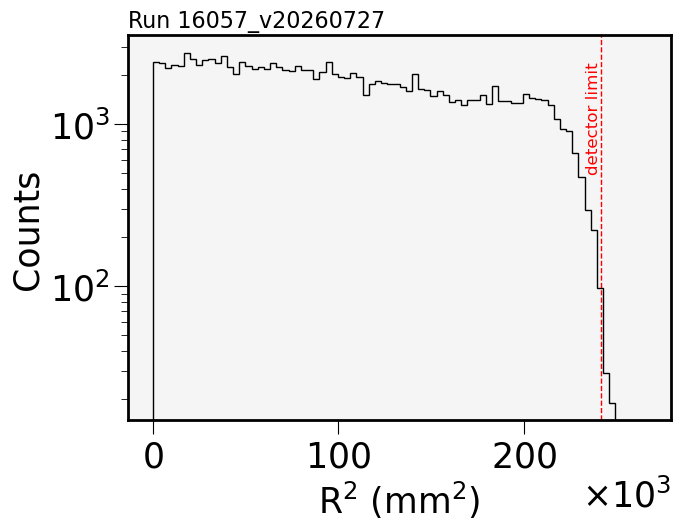

In [ ]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    R2 = doro_df['X']**2 + doro_df['Y']**2
    print(f"  - R² = [{R2.min():.2f}, {R2.max():.2f}] mm²")

    # Histogram
    counts, bins, _ = plt.hist(R2, bins=80, range=(R2.min(), 1.1*crudo.pt.N100_rad**2), histtype='step', color='black', lw=1.0)

    # Plot
    plt.xlabel('R$^{2}$ (mm$^{2}$)')
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    plt.title(f'Run {key}', loc='left', fontsize=16)
    # Radial line
    plt.axvline(x=crudo.pt.N100_rad**2, c='red', ls='--', lw=1)
    plt.text(crudo.pt.N100_rad**2, counts[0], 'detector limit', c='red', va='top',  ha='right',  rotation=90, fontsize=12)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

## ΔT

Run 16047_v20260727:
  - DT = [-999999.00, 2445.48] μs
  - There are 658 negative DT values
  - Cathode position = (534.95 ± 15.28) μs


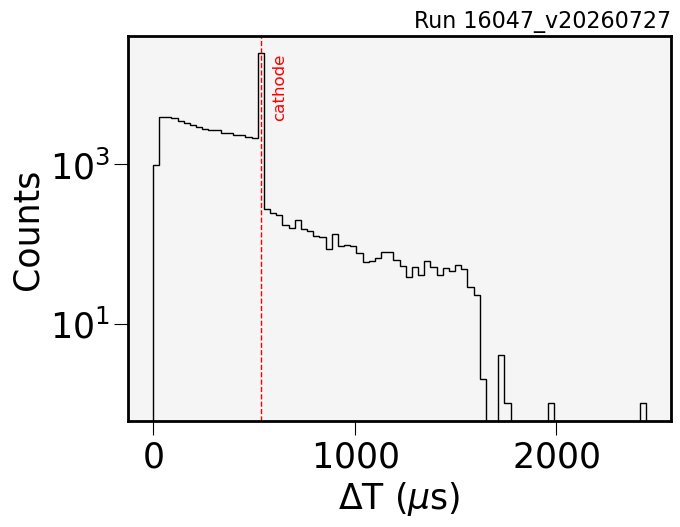

Run 16057_v20260727:
  - DT = [-999999.00, 2545.47] μs
  - There are 1092 negative DT values
  - Cathode position = (525.00 ± 15.91) μs


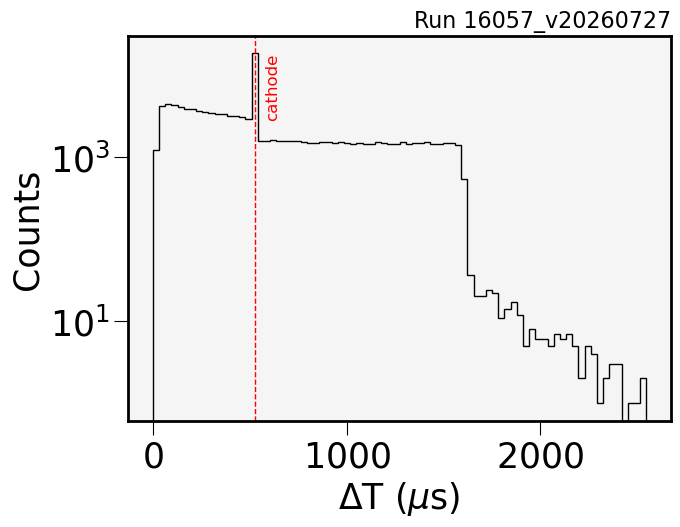

In [7]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    DT = doro_df['DT']
    print(f"  - DT = [{DT.min():.2f}, {DT.max():.2f}] μs")

    # Negative DT's?
    negative_DT = doro_df[DT < 0]    
    if not negative_DT.empty:
        print(f"  - There are {len(negative_DT)} negative DT values")
    else:
        print(f"  - No negative DT values found")

    # Histogram
    counts, bins, _ = plt.hist(DT, bins=80, range=(0, DT.max()), histtype='step', color='black', lw=1.0)

    # Estimated cathode time position + error
    cath_index   = np.argmax(counts)    # Index of the bin with the highest count
    cath_central = (bins[cath_index] + bins[cath_index + 1]) / 2 
    cath_error   = (bins[1] - bins[0]) / 2
    print(f"  - Cathode position = ({cath_central:.2f} ± {cath_error:.2f}) μs")

    # Plot
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cathode line
    plt.axvline(x=cath_central, c='red', ls='--', lw=1)
    plt.text(1.1*cath_central, counts[cath_index], 'cathode', c='red', va='top',  ha='left',  rotation=90, fontsize=12)
    # plt.axvline(x=EXTRA_INFO[key]['cath_lim'], c='green', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

## $S1$ Pulse

Run 16047_v20260727:
  - S1 Width = [0.20, 10.00] μs


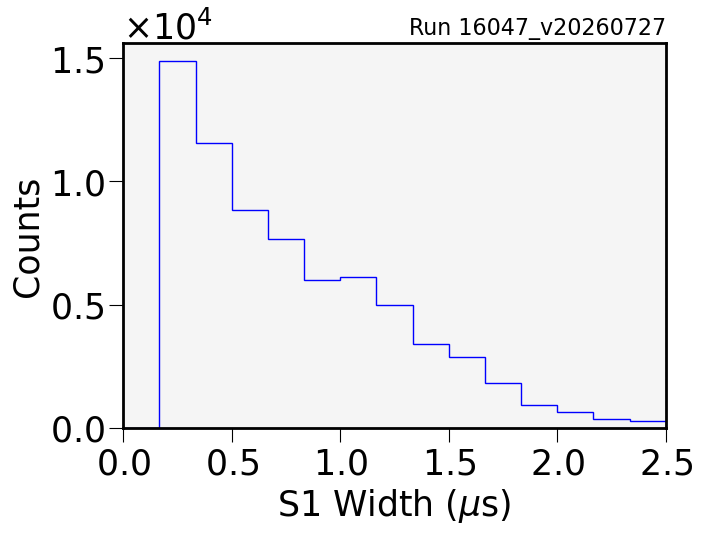

Run 16057_v20260727:
  - S1 Width = [0.20, 10.00] μs


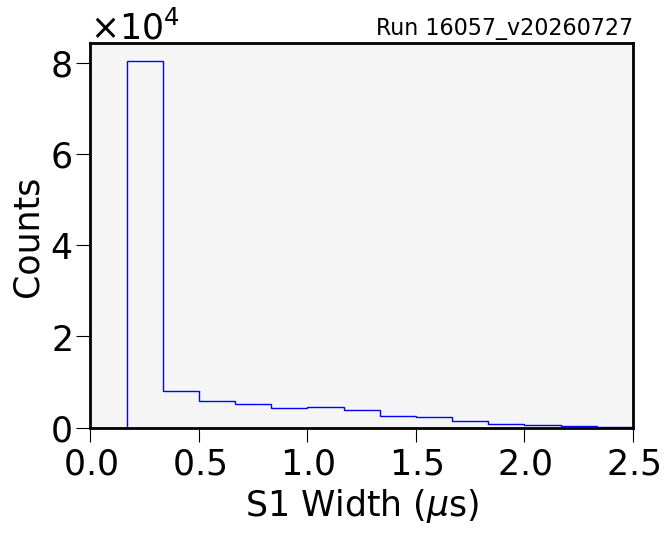

In [41]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    W1 = doro_df['S1w'] / 1e3   # [μs]
    print(f"  - S1 Width = [{W1.min():.2f}, {W1.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(W1, bins=15, range=(0, 2.5), histtype='step', color='blue', lw=1.0)

    # Plot
    plt.xlabel('S1 Width ($\mu$s)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    # plt.axvline(x=0.5, c='gray', ls='--', lw=1)
    plt.axvline(x=2.5, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

Run 16047_v20260727:
  - S1 Energy = [13.05, 18310.34] PE


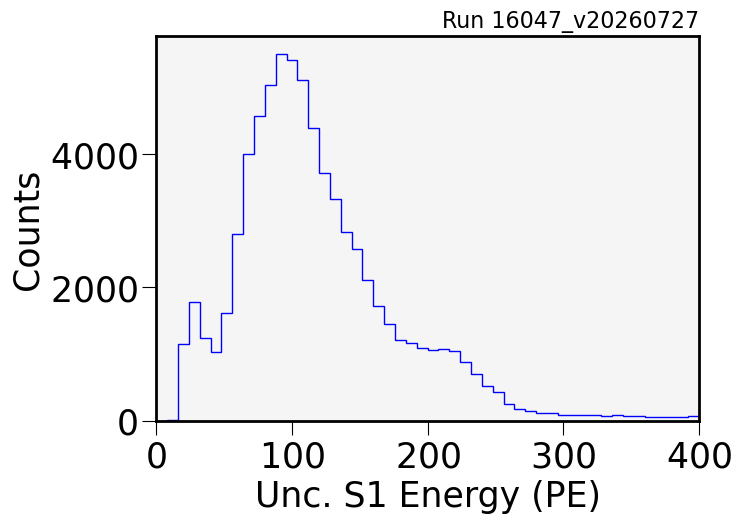

Run 16057_v20260727:
  - S1 Energy = [13.67, 18962.93] PE


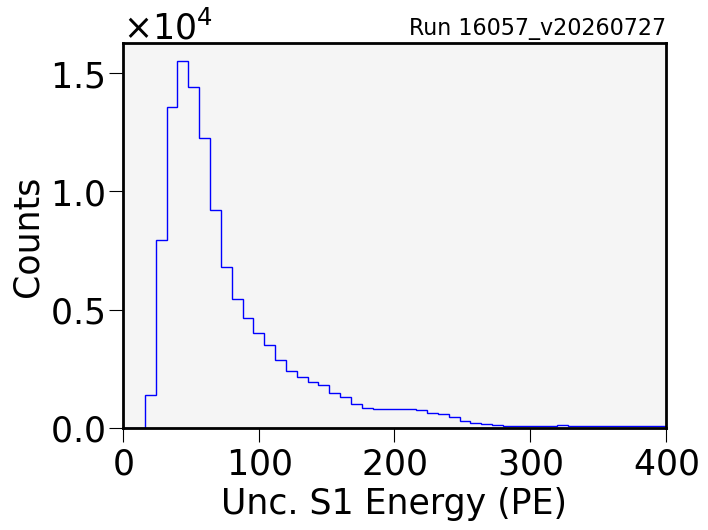

In [43]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    E1 = doro_df['S1e']
    print(f"  - S1 Energy = [{E1.min():.2f}, {E1.max():.2f}] PE")

    # Histogram
    counts, bins, _ = plt.hist(E1, bins=50, range=(0, 400), histtype='step', color='blue', lw=1.0)

    # Plot
    plt.xlabel('Unc. S1 Energy (PE)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    # plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    # plt.axvline(x=400, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

Run 16047_v20260727:
  - S1 Time = [0.88, 1579.90] μs


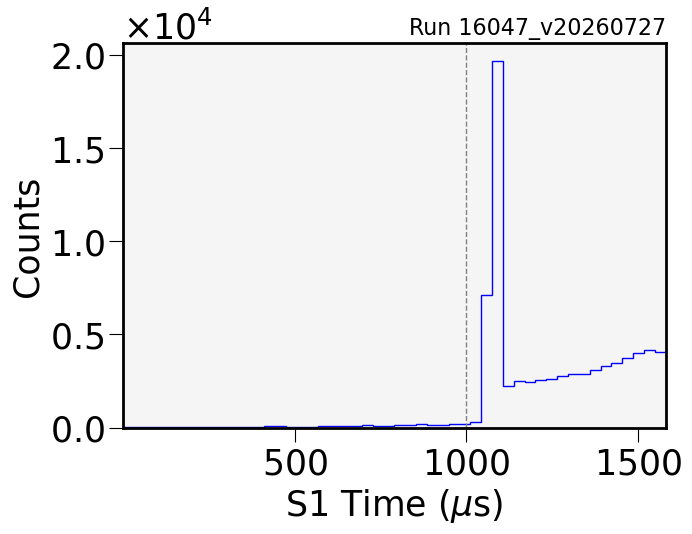

Run 16057_v20260727:
  - S1 Time = [0.07, 1579.92] μs


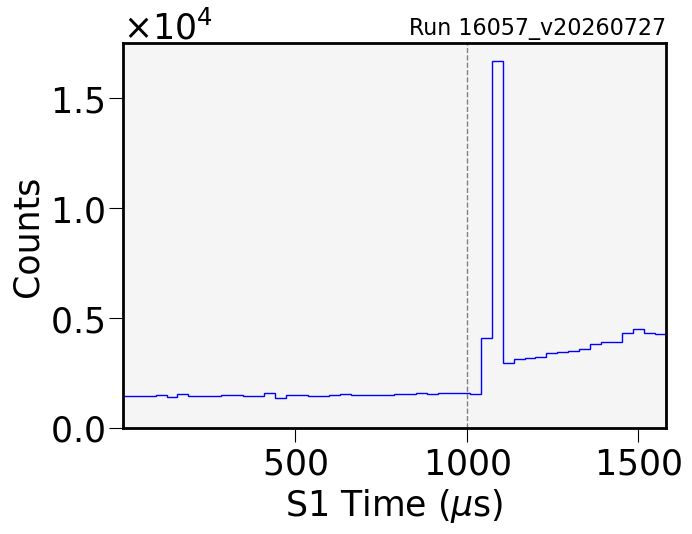

In [44]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    T1 = doro_df['S1t'] / 1e3   # [μs]
    print(f"  - S1 Time = [{T1.min():.2f}, {T1.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(T1, bins=50, histtype='step', color='blue', lw=1.0)

    # Plot
    plt.xlabel('S1 Time ($\mu$s)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    plt.axvline(x=1000, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

## $S2$ Pulse

Run 16047_v20260727:
  - S2 Width = [10.00, 1005.95] μs


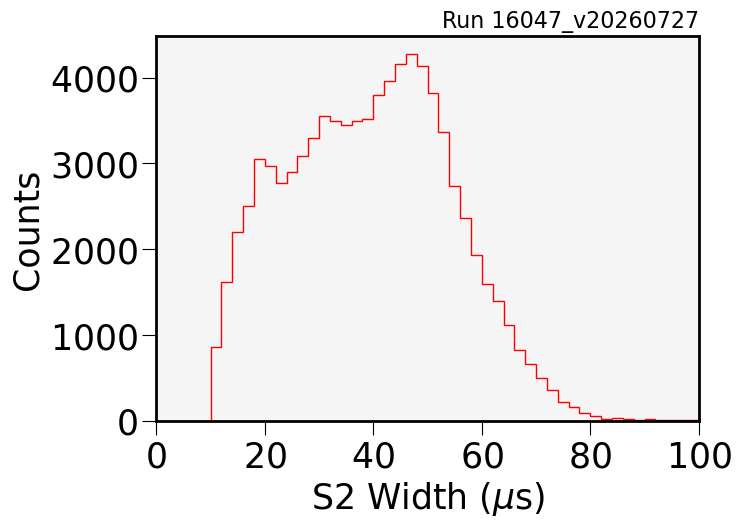

Run 16057_v20260727:
  - S2 Width = [10.00, 532.05] μs


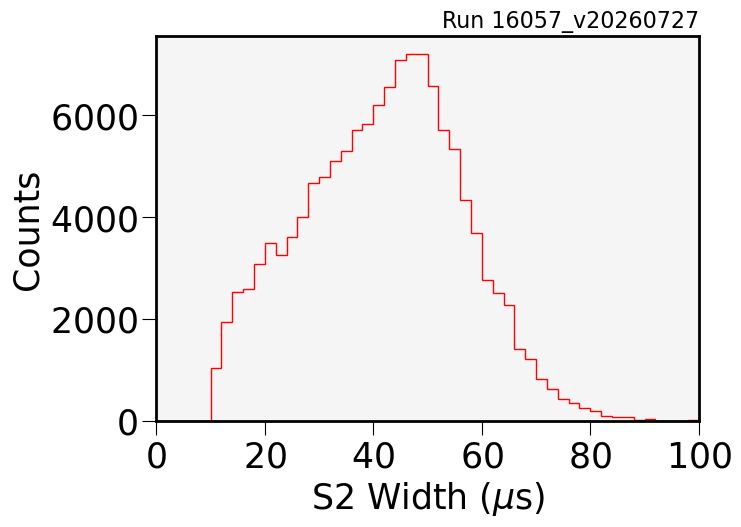

In [ ]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    W2 = doro_df['S2w']
    print(f"  - S2 Width = [{W2.min():.2f}, {W2.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(W2, bins=50, range=(0, 100), histtype='step', color='red', lw=1.0)

    # Plot
    plt.xlabel('S2 Width ($\mu$s)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    plt.axvline(x=100, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

Run 16047_v20260727:
  - S2 Energy = [261.98, 1108128.38] PE


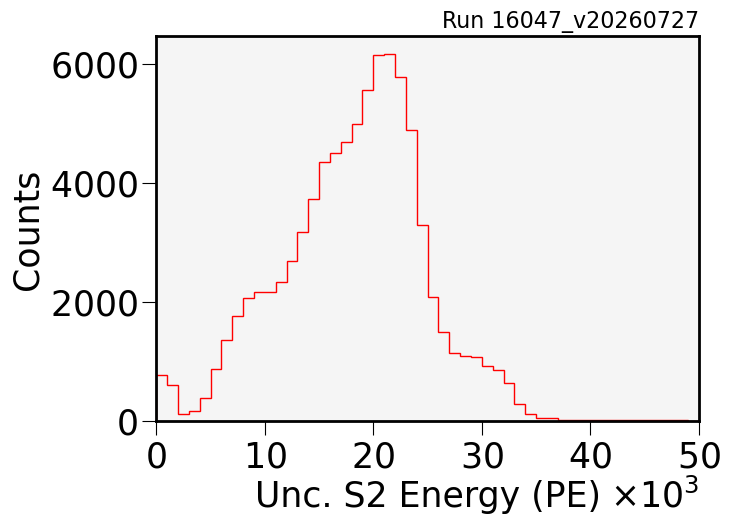

Run 16057_v20260727:
  - S2 Energy = [203.64, 633052.38] PE


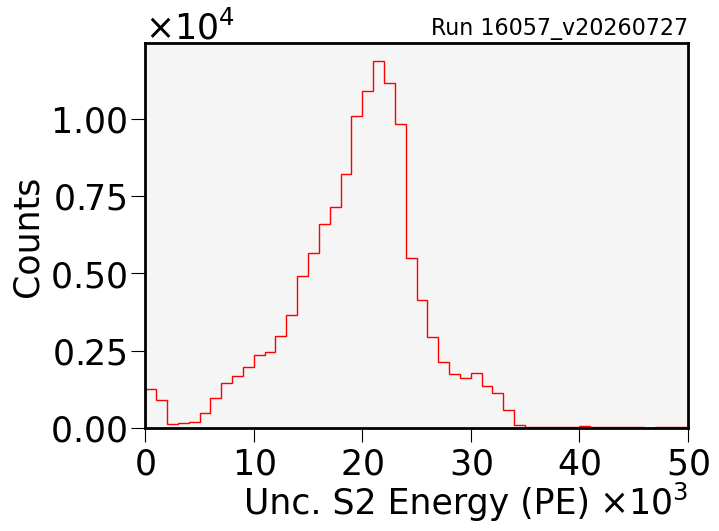

In [21]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    E2 = doro_df['S2e']
    print(f"  - S2 Energy = [{E2.min():.2f}, {E2.max():.2f}] PE")

    # Histogram
    counts, bins, _ = plt.hist(E2, bins=50, range=(0, 50e3), histtype='step', color='red', lw=1.0)

    # Plot
    plt.xlabel('Unc. S2 Energy (PE)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    # plt.axvline(x=5e3, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

Run 16047_v0727:
  - S2 Time = [1584.20, 2598.99] μs


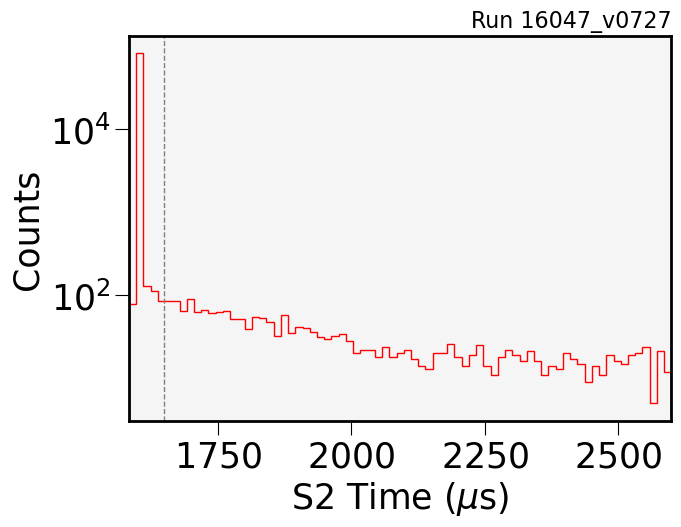

Run 16057_v0727:
  - S2 Time = [1580.88, 2596.00] μs


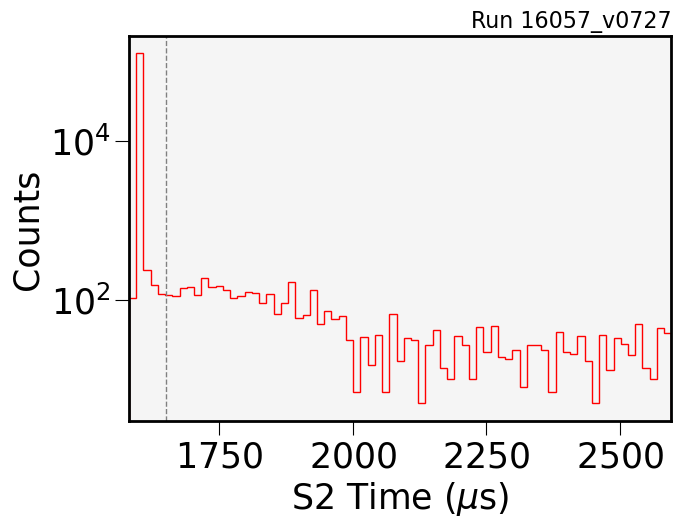

In [45]:
for key in DORO_DICT.keys():

    print(f"Run {key}:")
    doro_df = DORO_DICT[key]

    # Variables
    T2 = doro_df['S2t'] / 1e3   # [μs]
    print(f"  - S2 Time = [{T2.min():.2f}, {T2.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(T2, bins=75, histtype='step', color='red', lw=1.0)

    # Plot
    plt.xlabel('S2 Time ($\mu$s)')
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    plt.axvline(x=1650, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

# Selection

In [7]:
for key in DORO_DICT.keys():

    print(f"\nRun {key}:")
    doro_df = DORO_DICT[key]

    # Total number of events
    total_events = doro_df['event'].nunique()
    print(f"  Initially: {total_events} events")

    # Start with full dataset
    temp_df = doro_df.copy()

    # Apply each cut step by step
    for label, condition in SELECTION_CRITERIA['Ar']:

        temp_df = temp_df.groupby('event').filter(condition)
        rem_events  = temp_df['event'].nunique()
        
        print(f"  After {label}: {rem_events} events ({(rem_events / total_events) * 100:.2f}%)")

    # Store final selected data
    SEL_DICT[key] = temp_df.copy()


Run 16047_v20260727:
  Initially: 68921 events
  After Multiplicities: 51870 events (75.26%)
  After S1 Width: 51704 events (75.02%)
  After S1 Time: 51671 events (74.97%)
  After S2 Width: 51664 events (74.96%)
  After S2 Time: 51647 events (74.94%)

Run 16057_v20260727:
  Initially: 48245 events
  After Multiplicities: 32361 events (67.08%)
  After S1 Width: 32215 events (66.77%)
  After S1 Time: 32197 events (66.74%)
  After S2 Width: 32192 events (66.73%)
  After S2 Time: 32172 events (66.68%)


In [72]:
SEL_DICT

{'16047':        event          time  s1_peak  s2_peak  nS1  nS2     S1w        S1h  \
 0          8  1.784798e+09        0        0    1    1  2375.0  18.987965   
 1         15  1.784798e+09        0        0    1    1   825.0  13.149719   
 2         36  1.784798e+09        0        0    1    1  1925.0  14.803468   
 5         64  1.784798e+09        0        0    1    1  1550.0  17.715479   
 6         78  1.784798e+09        0        0    1    1  1075.0  10.043624   
 ...      ...           ...      ...      ...  ...  ...     ...        ...   
 12984  72555  1.784883e+09        0        0    1    1  1250.0  11.928771   
 12985  72590  1.784883e+09        0        0    1    1  2200.0  14.327103   
 12986  72618  1.784884e+09        0        0    1    1  1050.0  11.448949   
 12987  72751  1.784884e+09        0        0    1    1  1900.0  14.674635   
 12988  72765  1.784884e+09        0        0    1    1  2050.0  12.132091   
 
               S1e        S1t  ...  Nsipm          DT

Construct the _active volume_ mask to avoid the cathode

In [8]:
EXTRA_INFO = {}

for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # This mask defines the active volume (AV) in Z direction
    cath_lim = crudo.tf.get_cathode_limit(sel_df, n_bins=80, step_back=1)
    z_mask    = (sel_df['DT'] >= 0) & (sel_df['DT'] <= cath_lim)
    cath_mask = (sel_df['DT'] > cath_lim)

    EXTRA_INFO[key] = { 'cath_lim': cath_lim, 'AV_Z_mask': z_mask, 'cath_mask': cath_mask }


Run 16047_v20260727:
Cathode limit = 513.36 μs

Run 16057_v20260727:
Cathode limit = 515.01 μs


# Base Distributions (WITH CUTS!)

## Radial


Run 16047_v20260727:
  - R² = [3.45, 1999996000002.00] mm²


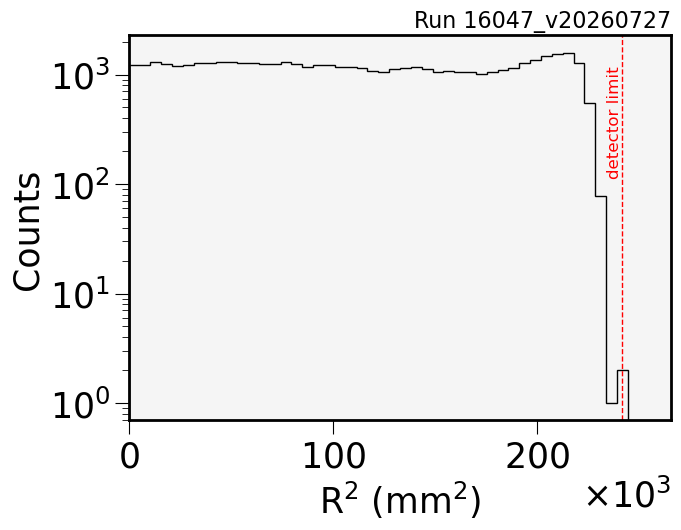


Run 16057_v20260727:
  - R² = [26.85, 233624.48] mm²


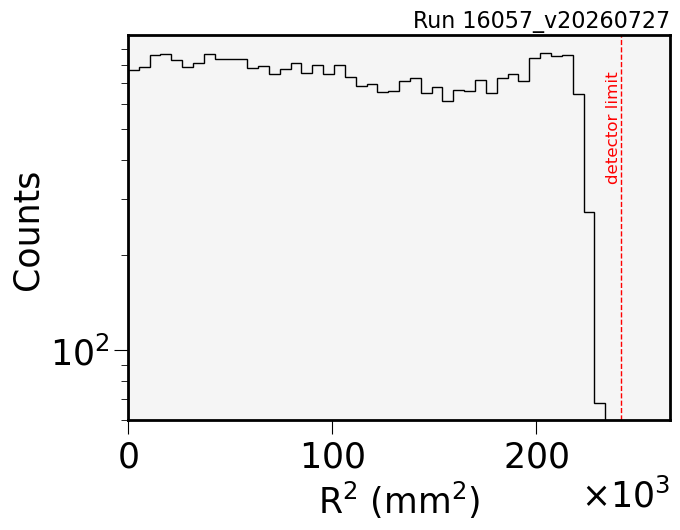

In [22]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    R2 = sel_df['X']**2 + sel_df['Y']**2
    print(f"  - R² = [{R2.min():.2f}, {R2.max():.2f}] mm²")

    # Histogram
    counts, bins, _ = plt.hist(R2, bins=50, range=(0, 1.1*crudo.pt.N100_rad**2), histtype='step', color='black', lw=1.0)

    # Plot
    plt.xlabel('R$^{2}$ (mm$^{2}$)')
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Radial line
    plt.axvline(x=crudo.pt.N100_rad**2, c='red', ls='--', lw=1)
    plt.text(crudo.pt.N100_rad**2, counts[0], 'detector limit', c='red', va='top',  ha='right',  rotation=90, fontsize=12)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

## ΔT


Run 16047_v20260727:
  - DT = [-999999.00, 586.69] μs
  - There are 8 negative DT values
  - Cathode position = (524.36 ± 3.67) μs


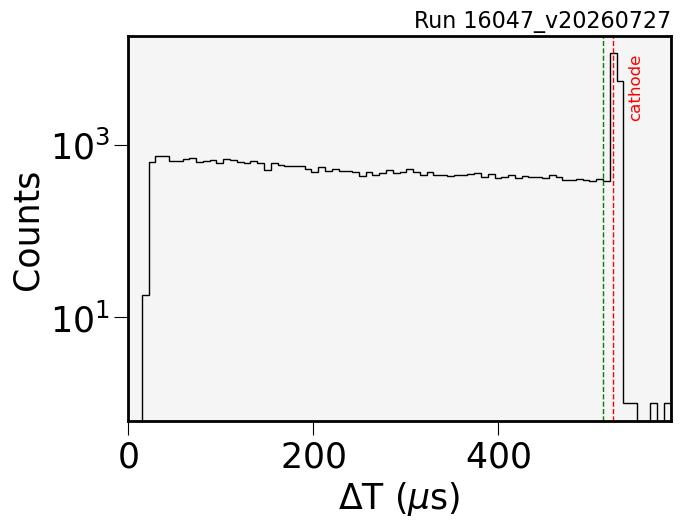


Run 16057_v20260727:
  - DT = [20.61, 597.11] μs
  - No negative DT values found
  - Cathode position = (526.20 ± 3.73) μs


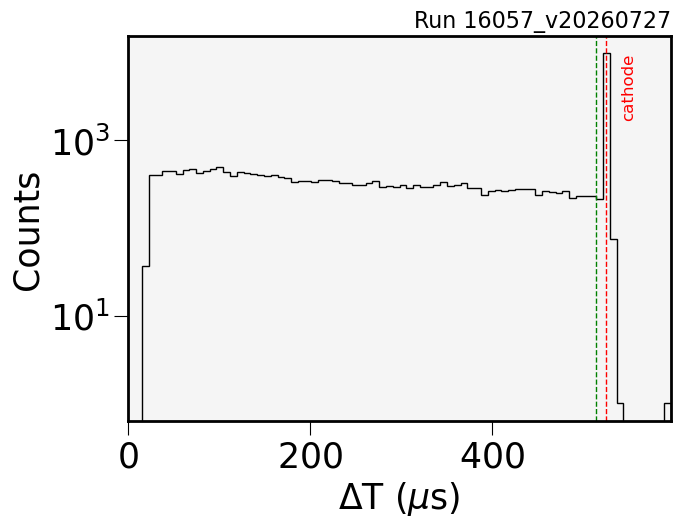

In [29]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    DT = sel_df['DT']
    print(f"  - DT = [{DT.min():.2f}, {DT.max():.2f}] μs")

    # Negative DT's?
    negative_DT = sel_df[DT < 0]    
    if not negative_DT.empty:
        print(f"  - There are {len(negative_DT)} negative DT values")
    else:
        print(f"  - No negative DT values found")

    # Histogram
    counts, bins, _ = plt.hist(DT, bins=80, range=(0, DT.max()), histtype='step', color='black', lw=1.0)

    # Estimated cathode time position + error
    cath_index   = np.argmax(counts)    # Index of the bin with the highest count
    cath_central = (bins[cath_index] + bins[cath_index + 1]) / 2 
    cath_error   = (bins[1] - bins[0]) / 2
    print(f"  - Cathode position = ({cath_central:.2f} ± {cath_error:.2f}) μs")

    # Plot
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cathode line
    plt.axvline(x=cath_central, c='red', ls='--', lw=1)
    plt.text(1.03*cath_central, counts[cath_index], 'cathode', c='red', va='top',  ha='left',  rotation=90, fontsize=12)
    plt.axvline(x=EXTRA_INFO[key]['cath_lim'], c='green', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

## $S1$ Pulse


Run 16047_v0727:
  - S1 Width = [0.20, 2.50] μs


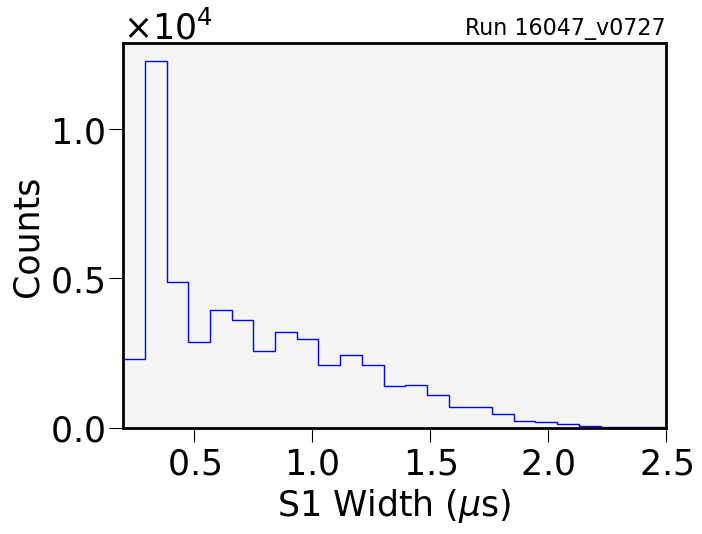


Run 16057_v0727:
  - S1 Width = [0.23, 2.50] μs


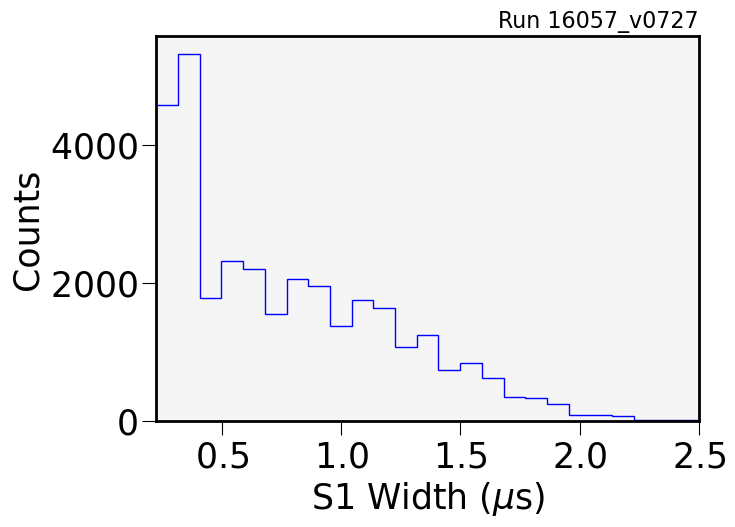

In [84]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    W1 = sel_df['S1w'] / 1e3   # [μs]
    print(f"  - S1 Width = [{W1.min():.2f}, {W1.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(W1, bins=25, range=None, histtype='step', color='blue', lw=1.0)

    # Plot
    plt.xlabel('S1 Width ($\mu$s)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.xlim(bins[0], bins[-1])
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    # plt.axvline(x=0.5, c='gray', ls='--', lw=1)
    # plt.axvline(x=4.5, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_v0727:
  - S1 Energy = [20.25, 345.58] PE


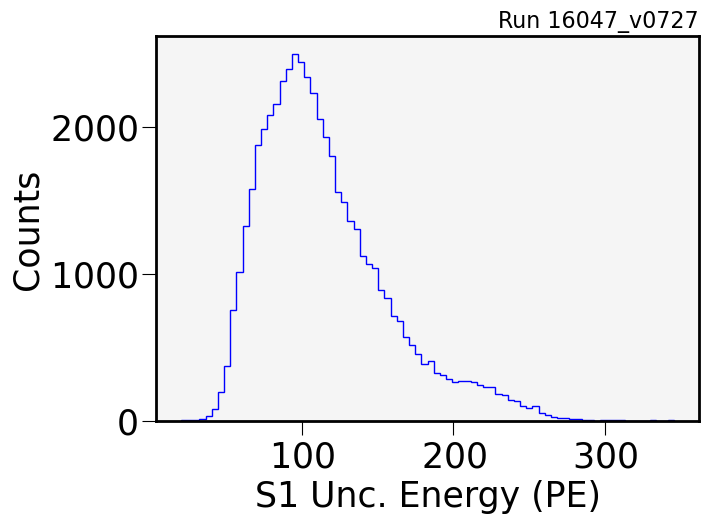


Run 16057_v0727:
  - S1 Energy = [17.96, 421.04] PE


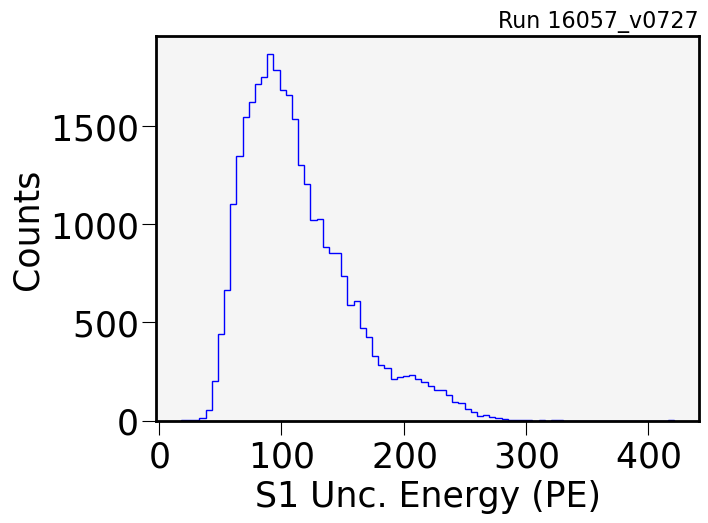

In [85]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    E1 = sel_df['S1e']
    print(f"  - S1 Energy = [{E1.min():.2f}, {E1.max():.2f}] PE")

    # Histogram
    counts, bins, _ = plt.hist(E1, bins=80, histtype='step', color='blue', lw=1.0)

    # Plot
    plt.xlabel('S1 Unc. Energy (PE)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    # plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    # plt.axvline(x=750, c='gray', ls='--', lw=1)
    # plt.axvline(x=1500, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_v0727:
  - S1 Time = [1015.33, 1579.85] μs


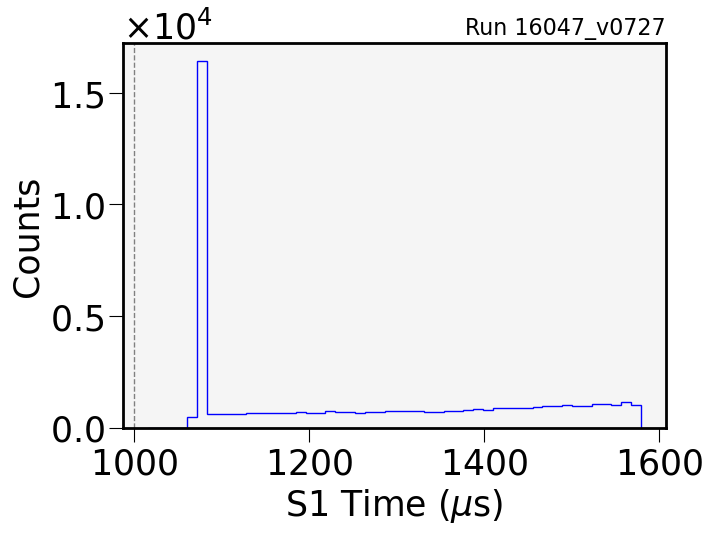


Run 16057_v0727:
  - S1 Time = [1004.80, 1579.83] μs


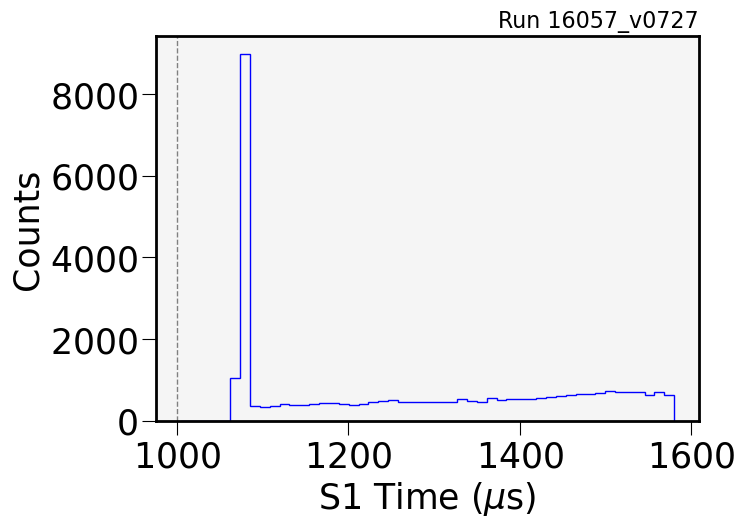

In [86]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    T1 = sel_df['S1t'] / 1e3   # [μs]
    print(f"  - S1 Time = [{T1.min():.2f}, {T1.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(T1, bins=50, histtype='step', color='blue', lw=1.0)

    # Plot
    plt.xlabel('S1 Time ($\mu$s)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    plt.axvline(x=1000, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

## $S2$ Pulse


Run 16047_v0727:
  - S2 Width = [10.07, 96.05] μs


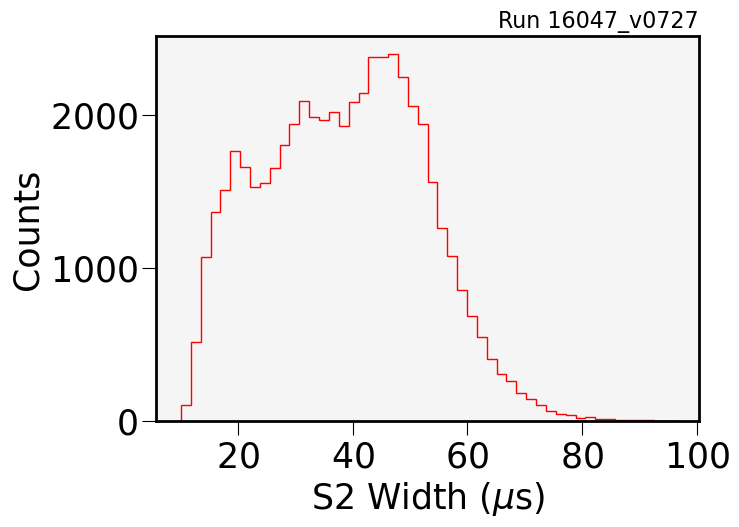


Run 16057_v0727:
  - S2 Width = [10.20, 95.70] μs


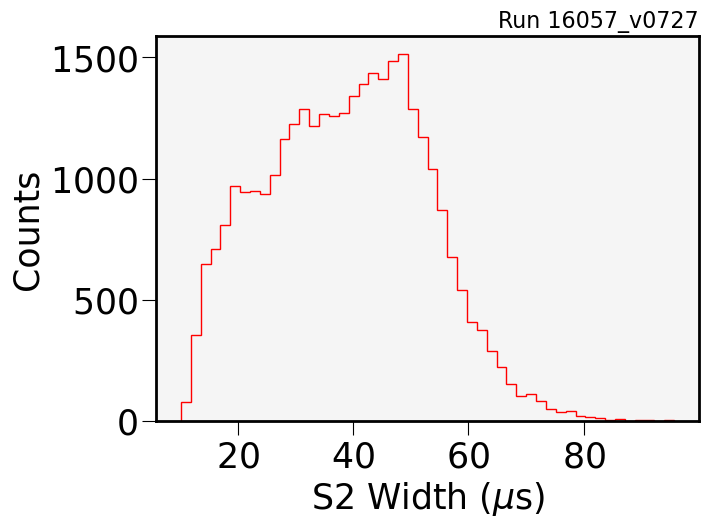

In [88]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    W2 = sel_df['S2w']
    print(f"  - S2 Width = [{W2.min():.2f}, {W2.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(W2, bins=50, histtype='step', color='red', lw=1.0)

    # Plot
    plt.xlabel('S2 Width ($\mu$s)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    # plt.axvline(x=35, c='gray', ls='--', lw=1)
    # plt.axvline(x=250, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_v0727:
  - S2 Energy = [434.34, 64868.00] PE


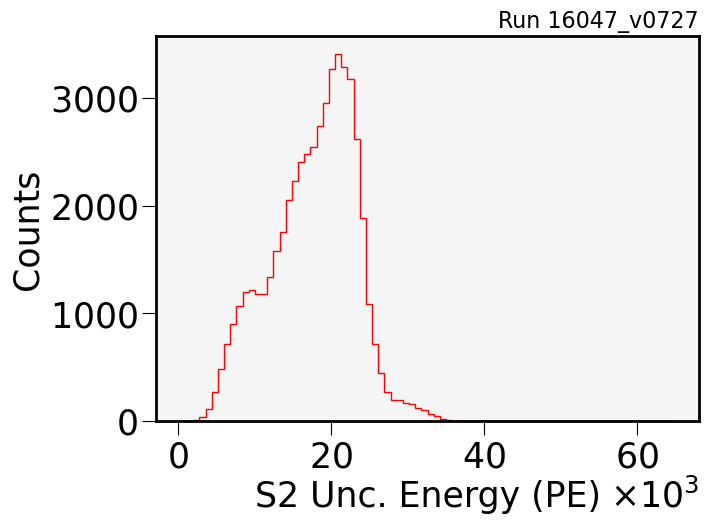


Run 16057_v0727:
  - S2 Energy = [2343.16, 47322.14] PE


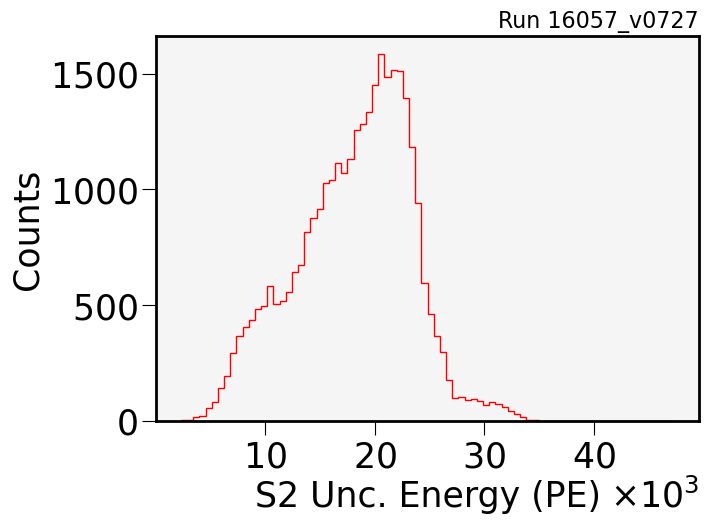

In [ ]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    E2 = sel_df['S2e']
    print(f"  - S2 Energy = [{E2.min():.2f}, {E2.max():.2f}] PE")

    # Histogram
    counts, bins, _ = plt.hist(E2, bins=80, range=None, histtype='step', color='red', lw=1.0)

    # Plot
    plt.xlabel('Unc. S2 Energy (PE)')
    plt.ylabel('Counts')
    # plt.yscale('log')
    plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    # plt.axvline(x=5e3, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_v0727:
  - S2 Time = [1595.02, 1644.83] μs


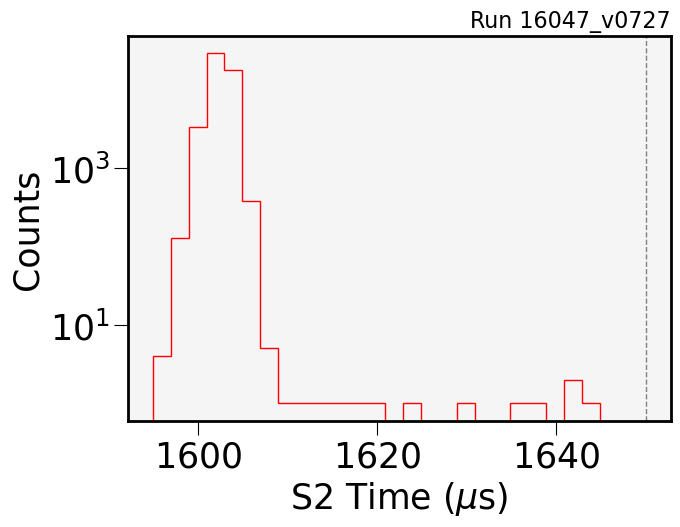


Run 16057_v0727:
  - S2 Time = [1596.98, 1645.04] μs


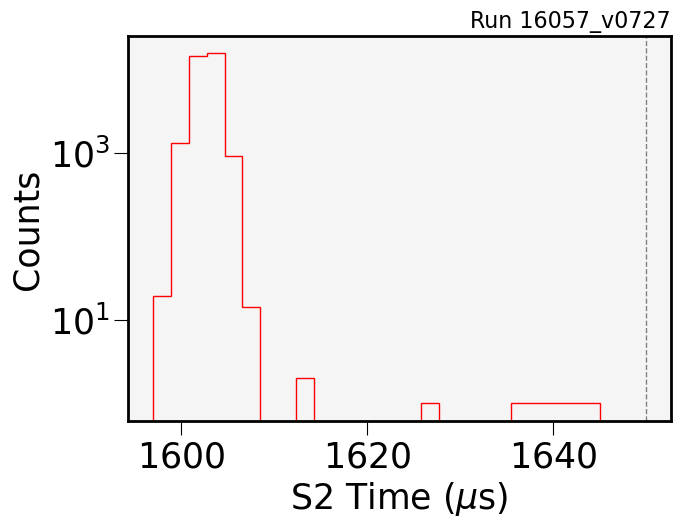

In [90]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables
    T2 = sel_df['S2t'] / 1e3   # [μs]
    print(f"  - S2 Time = [{T2.min():.2f}, {T2.max():.2f}] μs")

    # Histogram
    counts, bins, _ = plt.hist(T2, bins=25, histtype='step', color='red', lw=1.0)

    # Plot
    plt.xlabel('S2 Time ($\mu$s)')
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.title(f'Run {key}', loc='right', fontsize=16)
    # Cut line
    plt.axvline(x=1650, c='gray', ls='--', lw=1)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

# Control Plots

## Maps

### Event


Run 16047_v20260727:


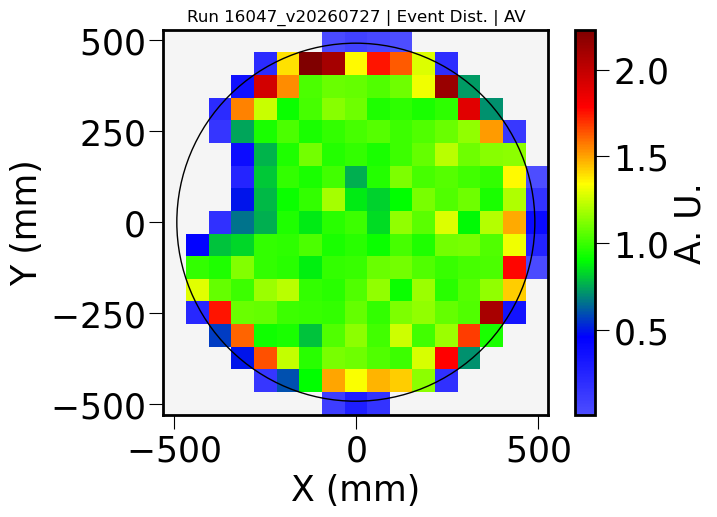


Run 16057_v20260727:


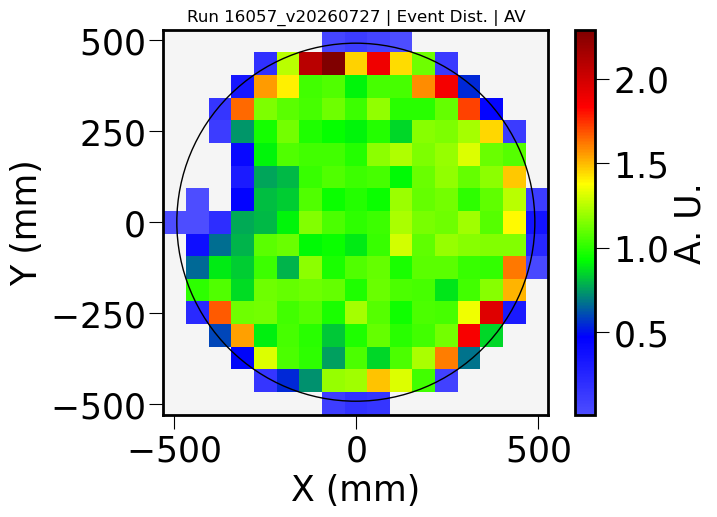

In [21]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    X = sel_df['X']
    Y = sel_df['Y']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask'])
    X_mask = X[mask]
    Y_mask = Y[mask]

    # Map
    xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=4, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
    xy_map         = np.ma.masked_where(xy_map==0, xy_map)

    # Plot
    plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(label='A. U.')
    # cbar.set_ticks([0.6, 0.8, 1.0, 1.2, 1.4])
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Run {key} | Event Dist. | AV', loc='center', fontsize=12) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_v20260727:


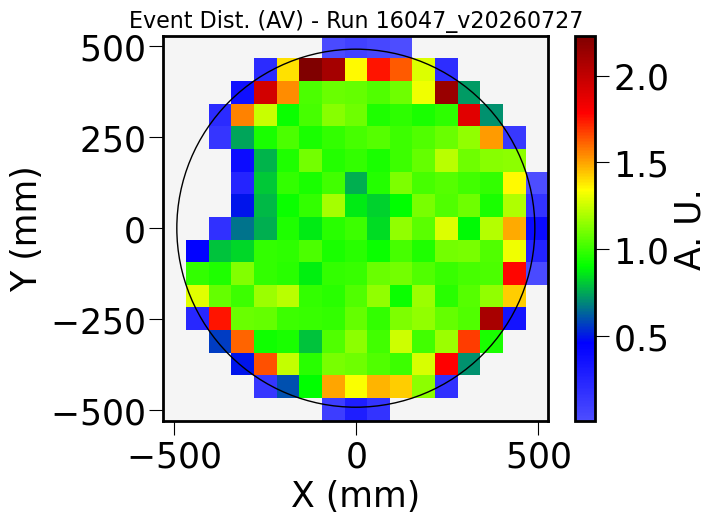


Run 16057_v20260727:


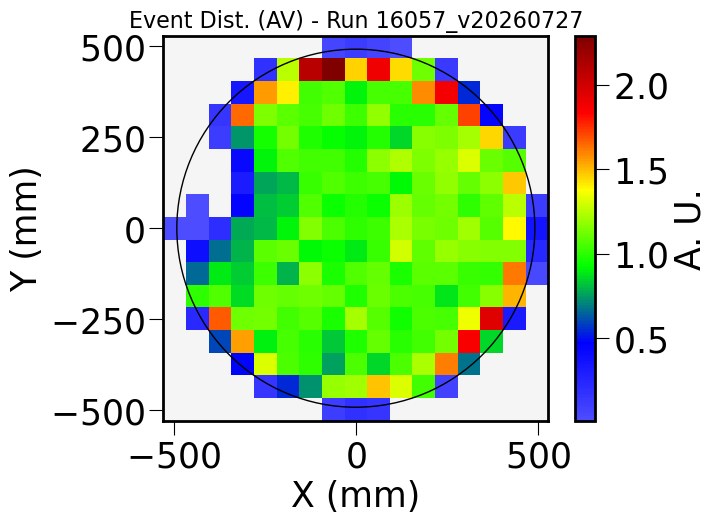

In [7]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    X = sel_df['X']
    Y = sel_df['Y']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask'])
    X_mask = X[mask]
    Y_mask = Y[mask]

    # Map
    xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=4, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
    xy_map         = np.ma.masked_where(xy_map==0, xy_map)
    # xy_map         = np.clip(xy_map, 0.5, 1.5)

    # Plot
    plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='A. U.')
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Event Dist. (AV) - Run {key}', loc='center', fontsize=16) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### Energy


Run 16047_v20260727:


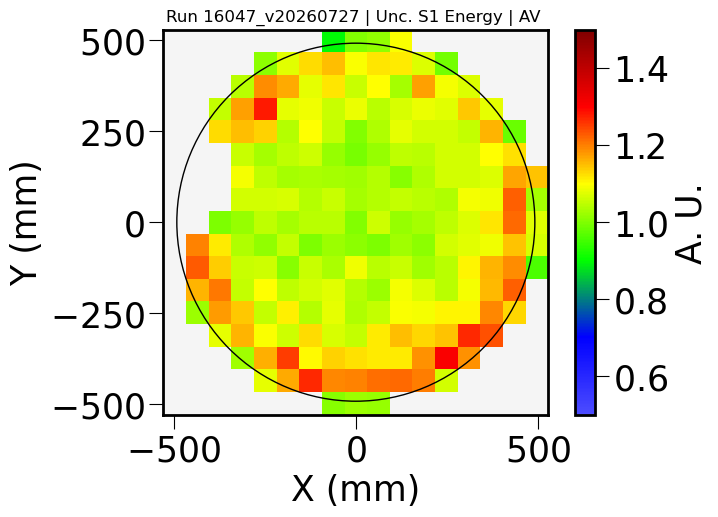


Run 16057_v20260727:


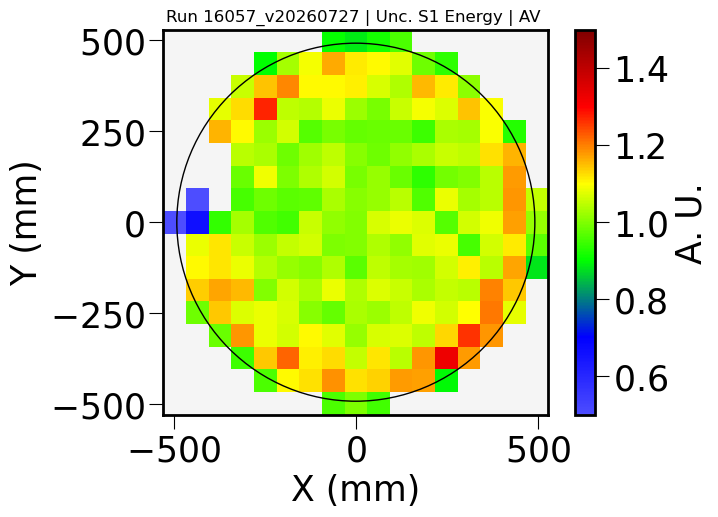

In [ ]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    X = sel_df['X']
    Y = sel_df['Y']
    E1 = sel_df['S1e']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask'])
    X_mask = X[mask]
    Y_mask = Y[mask]
    E1_mask = E1[mask]

    # Map
    s1e_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=E1_mask, bin_scale=4, max_limit=crudo.pt.N100_rad, norm=True)
    s1e_map         = np.ma.masked_where(s1e_map==0, s1e_map)

    # Plot
    plt.pcolormesh(ex, ey, s1e_map.T, cmap=crudo.pt.custom_hsv, shading='auto', vmin=0.5, vmax=1.5)
    cbar = plt.colorbar(label='A. U.')
    cbar.set_ticks([0.6, 0.8, 1.0, 1.2, 1.4])
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Run {key} | Unc. S1 Energy | AV', loc='center', fontsize=12) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_v20260727:


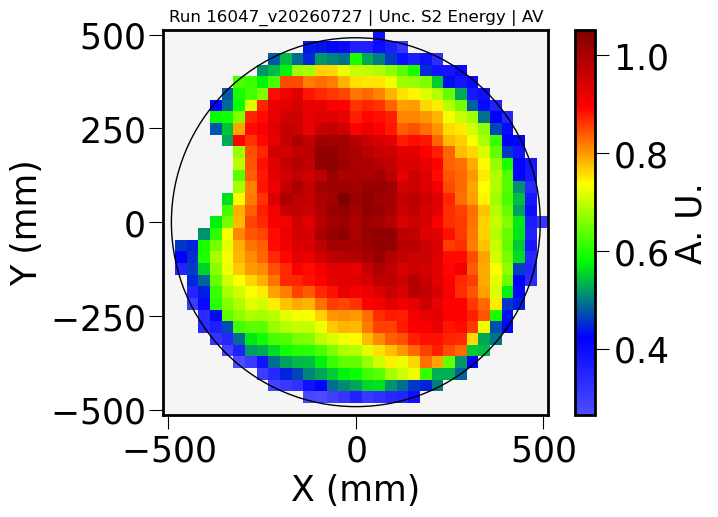


Run 16057_v20260727:


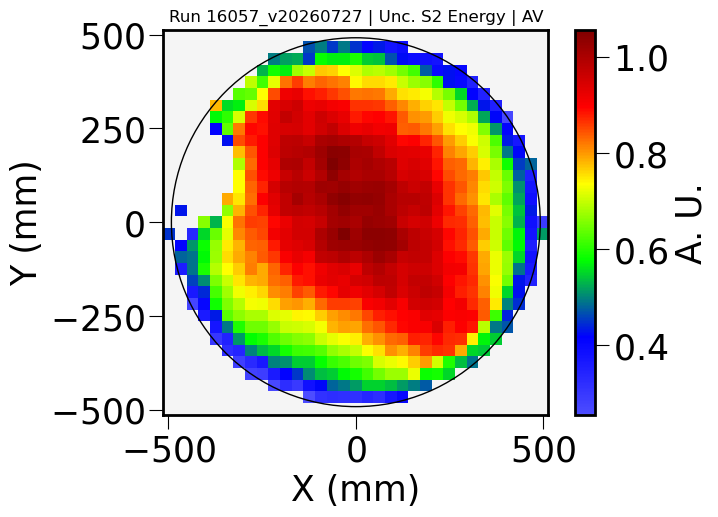

In [63]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    X = sel_df['X']
    Y = sel_df['Y']
    E2 = sel_df['S2e']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask'])
    X_mask = X[mask]
    Y_mask = Y[mask]
    E2_mask = E2[mask]

    # Map
    s2e_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=E2_mask,  bin_scale=2, max_limit=crudo.pt.N100_rad, norm=True)
    s2e_map         = np.ma.masked_where(s2e_map==0, s2e_map)

    # Plot
    plt.pcolormesh(ex, ey, s2e_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(label='A. U.')
    # cbar.set_ticks([0.6, 0.8, 1.0, 1.2, 1.4])
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Run {key} | Unc. S2 Energy | AV', loc='center', fontsize=12) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### Width


Run 16047_v0727:


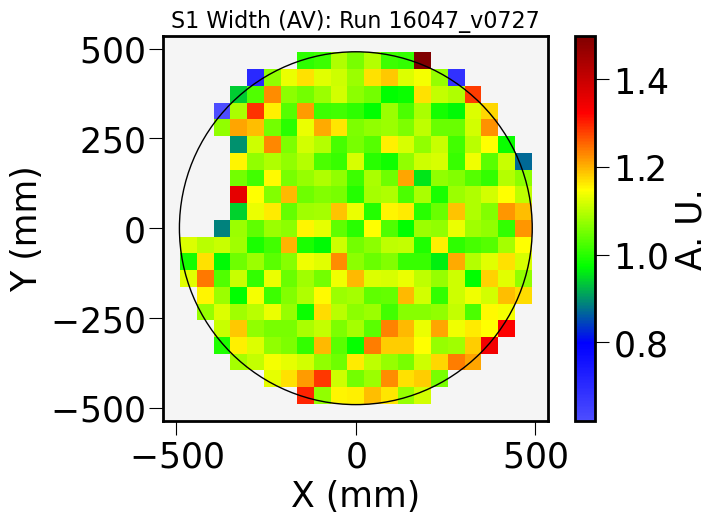


Run 16057_v0727:


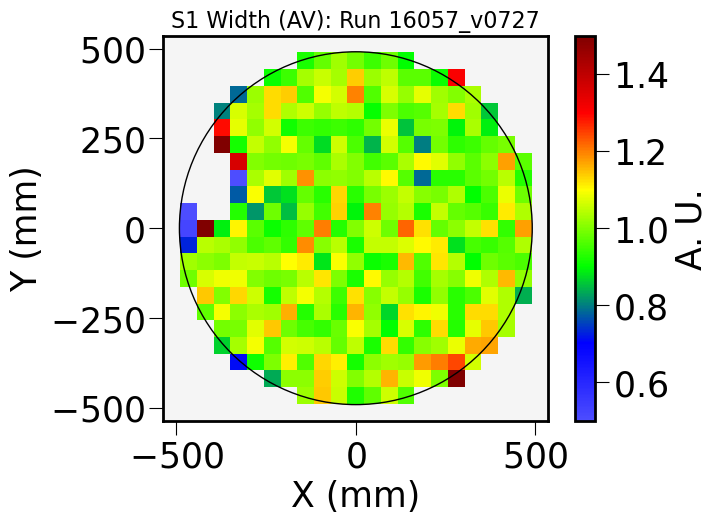

In [112]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    X = sel_df['X']
    Y = sel_df['Y']
    W1 = sel_df['S1w']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask'])
    X_mask = X[mask]
    Y_mask = Y[mask]
    W1_mask = W1[mask]

    # Map
    s1w_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=W1_mask,bin_scale=3, max_limit=crudo.pt.N100_rad, norm=True)
    s1w_map         = np.ma.masked_where(s1w_map==0, s1w_map)
    s1w_map         = np.clip(s1w_map, 0.5, 1.5)

    # Plot
    plt.pcolormesh(ex, ey, s1w_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='A. U.')
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'S1 Width (AV): Run {key}', loc='center', fontsize=16) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_v0727:


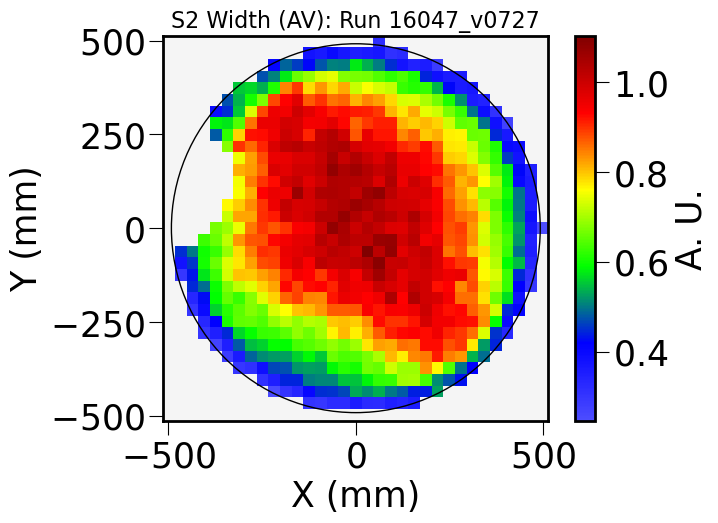


Run 16057_v0727:


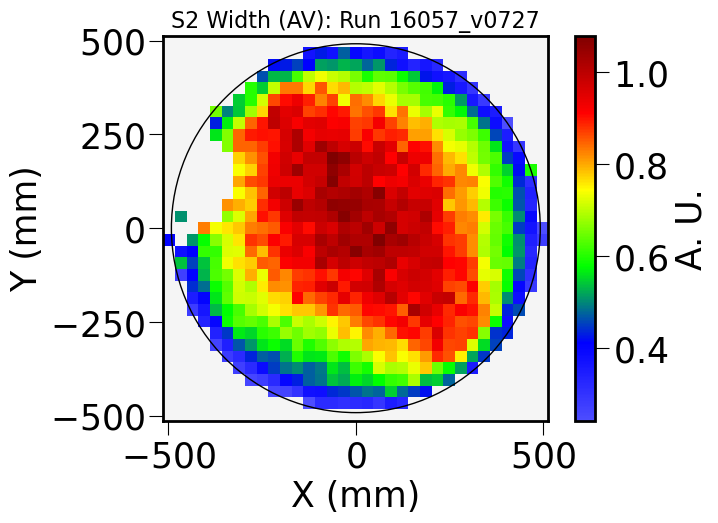

In [113]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    X = sel_df['X']
    Y = sel_df['Y']
    W2 = sel_df['S2w']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask'])
    X_mask = X[mask]
    Y_mask = Y[mask]
    W2_mask = W2[mask]

    # Map
    s2w_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=W2_mask, bin_scale=2, max_limit=crudo.pt.N100_rad, norm=True)
    s2w_map         = np.ma.masked_where(s2w_map==0, s2w_map)
    # s2w_map         = np.clip(s2w_map, 0.5, 1.5)

    # Plot
    plt.pcolormesh(ex, ey, s2w_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='A. U.')
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'S2 Width (AV): Run {key}', loc='center', fontsize=16) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

## 2D Histograms

### Energy


Run 16047:


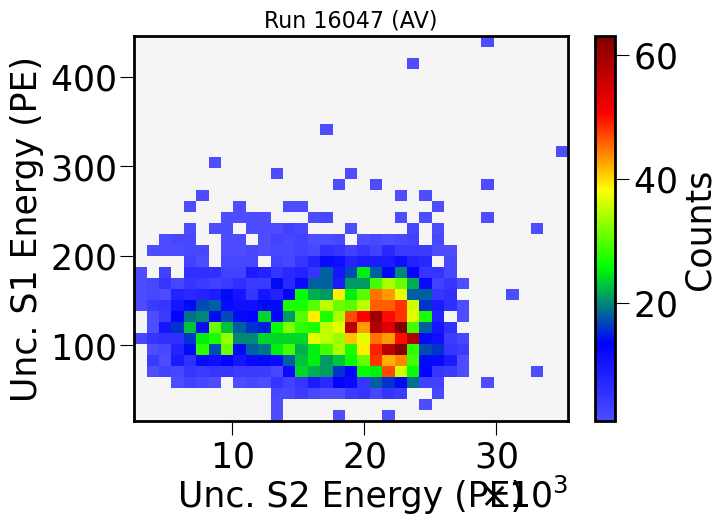


Run 16057:


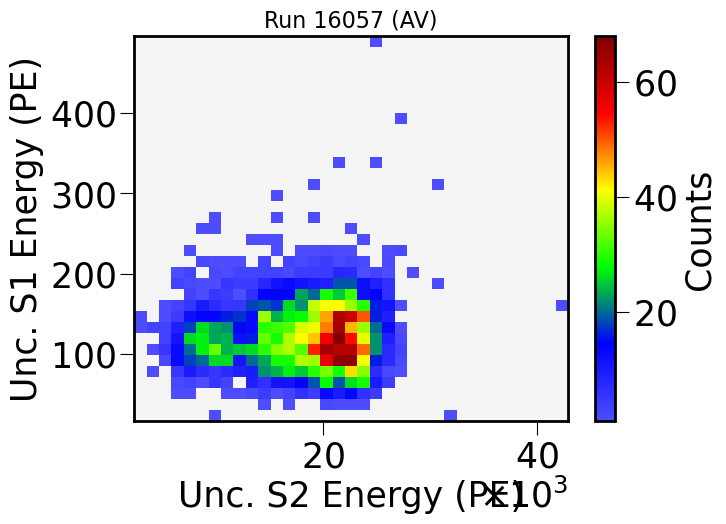


Run 16047_v0727:


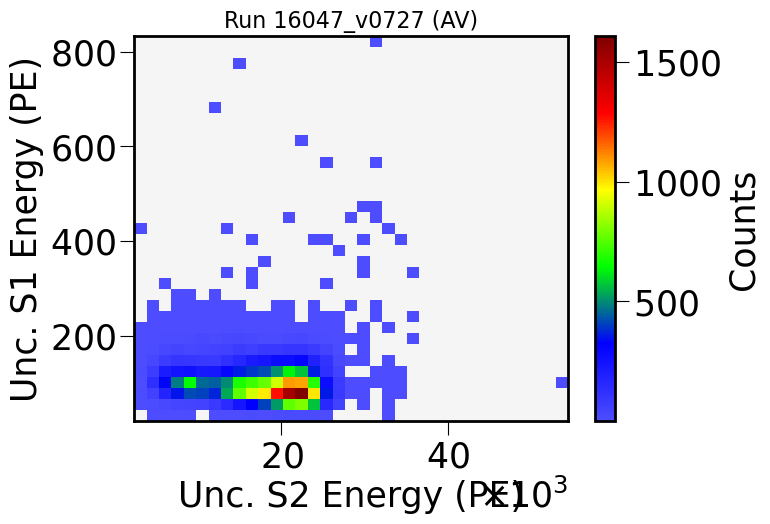


Run 16057_v0727:


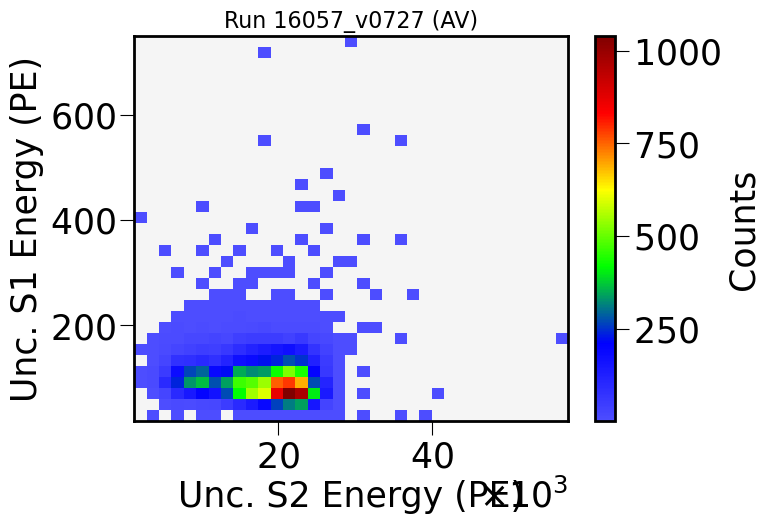

In [115]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    E1 = sel_df['S1e']
    E2 = sel_df['S2e']
    R = np.sqrt(sel_df['X']**2 + sel_df['Y']**2)

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask']) & (R <= 500)
    E1_mask = E1[mask]
    E2_mask = E2[mask]

    # 2D Histogram
    s1e_s2e_map, ex, ey = np.histogram2d(E2_mask, E1_mask, bins=[35, 35])
    s1e_s2e_map         = np.ma.masked_where(s1e_s2e_map==0, s1e_s2e_map)

    # Plot
    plt.pcolormesh(ex, ey, s1e_s2e_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('Unc. S2 Energy (PE)')
    plt.ylabel('Unc. S1 Energy (PE)')
    plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    plt.title (f'Run {key} (AV)', loc='center', fontsize=16) 

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### Light Collection


Run 16047_v20260727:


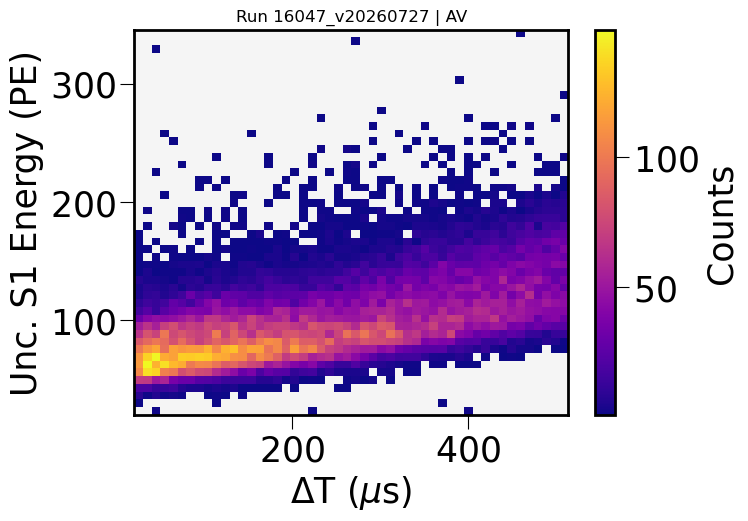


Run 16057_v20260727:


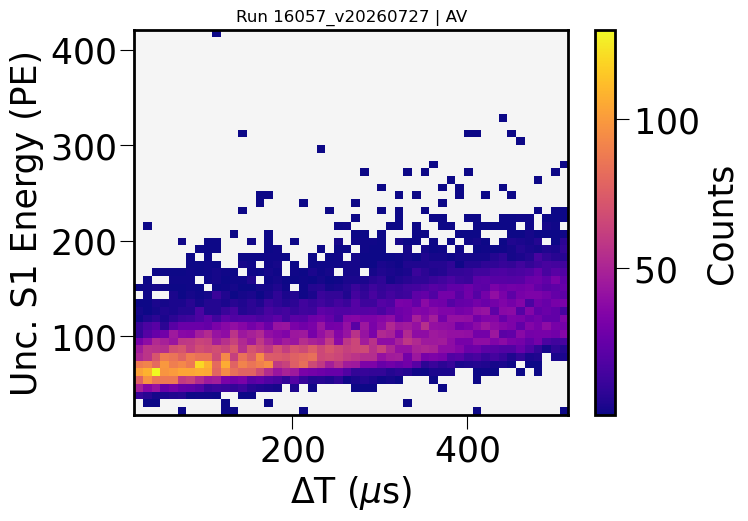

In [85]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    E1 = sel_df['S1e']
    DT = sel_df['DT']
    R = np.sqrt(sel_df['X']**2 + sel_df['Y']**2)

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask']) & (R <= 500)
    E1_mask = E1[mask]
    DT_mask = DT[mask]

    # 2D Histogram
    s1e_dt_map, ex, ey = np.histogram2d(DT_mask, E1_mask, bins=[50, 50])
    s1e_dt_map         = np.ma.masked_where(s1e_dt_map==0, s1e_dt_map)

    # Plot
    plt.pcolormesh(ex, ey, s1e_dt_map.T, cmap='plasma', shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.ylabel('Unc. S1 Energy (PE)')
    plt.title (f'Run {key} | AV', loc='center', fontsize=12) 

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### Lifetime


Run 16047_v20260727:


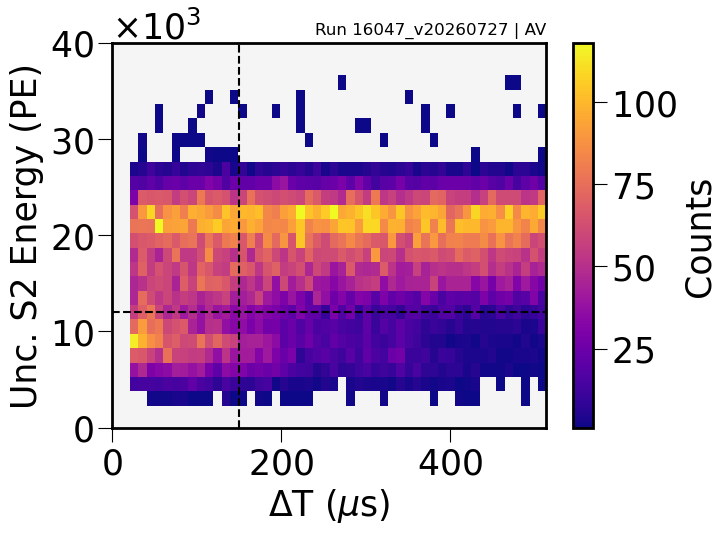


Run 16057_v20260727:


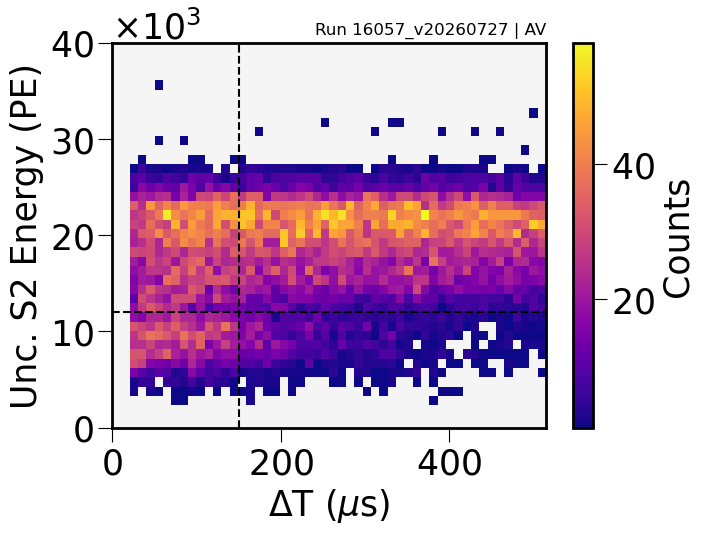

In [70]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    E2 = sel_df['S2e']
    DT = sel_df['DT']
    R = np.sqrt(sel_df['X']**2 + sel_df['Y']**2)

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask']) & (R <= 500)
    E2_mask = E2[mask]
    DT_mask = DT[mask]

    # 2D Histogram
    s2e_dt_map, ex, ey = np.histogram2d(DT_mask, E2_mask, bins=[50, 35])
    s2e_dt_map         = np.ma.masked_where(s2e_dt_map==0, s2e_dt_map)

    # Plot
    plt.pcolormesh(ex, ey, s2e_dt_map.T, cmap='plasma', shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.xlim(0, DT_mask.max())
    plt.ylim(0, 40e3)
    plt.ylabel('Unc. S2 Energy (PE)')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title (f'Run {key} | AV', loc='right', fontsize=12)

    # Lines
    plt.axvline(x=150, c='black', ls='--', lw=1.5)
    plt.axhline(y=12e3, c='black', ls='--', lw=1.5)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

HACER S2W VS DT!

HACER S2W VS S1H y asi

# Extras


Run 16047_v20260727:


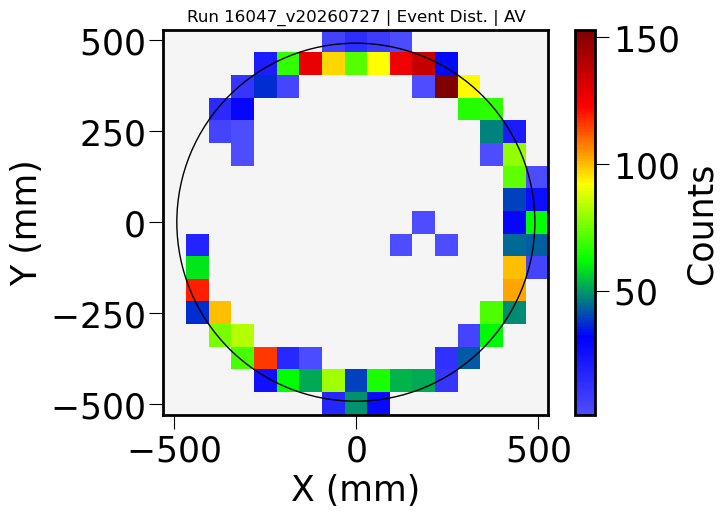


Run 16057_v20260727:


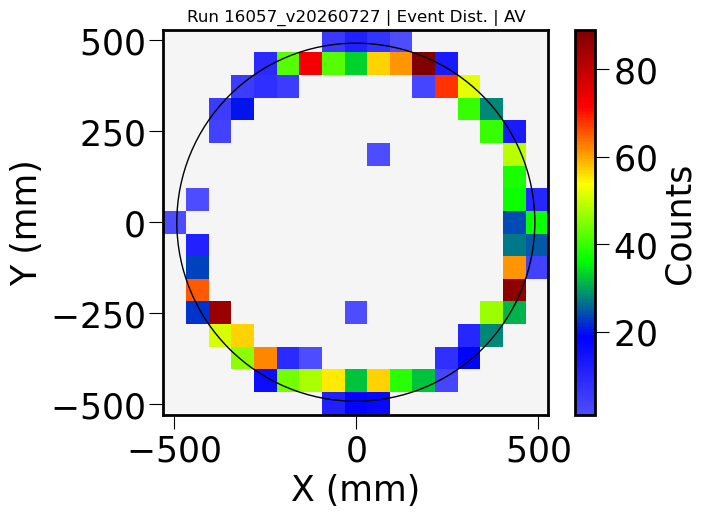

In [84]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    sel_df = SEL_DICT[key]

    # Variables    
    X = sel_df['X']
    Y = sel_df['Y']
    DT = sel_df['DT']
    E2 = sel_df['S2e']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask']) & (E2 <= 12e3) & (DT <= 150)
    X_mask = X[mask]
    Y_mask = Y[mask]

    # Map
    xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=4, max_limit=crudo.pt.N100_rad, pos=True, norm=False)
    xy_map         = np.ma.masked_where(xy_map==0, xy_map)
    # xy_map         = np.clip(xy_map, 0.5, 1.5)

    # Plot
    plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(label='Counts')
    # cbar.set_ticks([0.6, 0.8, 1.0, 1.2, 1.4])
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Run {key} | Event Dist. | AV', loc='center', fontsize=12) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()